In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # 设置可见的GPU设备

import argparse
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
# from torch.optim.lr_scheduler import LambdaLR

def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )


def train(dataset, model, prog_args, val_dataset=None, checkpoint=None):
    """
    training function
    """
    liveloss = PlotLosses()

    # 初始化模型存储路径
    if not os.path.exists(prog_args.save_dir + "/" + prog_args.dataset):
        os.makedirs(prog_args.save_dir + "/" + prog_args.dataset)
    elif checkpoint is None:
        shutil.rmtree(prog_args.save_dir + "/" + prog_args.dataset)
        os.makedirs(prog_args.save_dir + "/" + prog_args.dataset)

    f_train_log = open(prog_args.save_dir + "/" + prog_args.dataset + "/train_log.csv", 'w')
    f_train_log.write("{}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}\n".format('epoch', 'accuracy', 'val_accuracy', 'F1 score', 'val_F1 score',
                                                                                                                                    'Class 1 F1 score', 'val_Class 1 F1 score',
                                                                                                                                    'Class 2 F1 score', 'val_Class 2 F1 score',
                                                                                                                                    'Class 3 F1 score', 'val_Class 3 F1 score',
                                                                                                                                    'Class 4 F1 score', 'val_Class 4 F1 score',
                                                                                                                                    'Class 5 F1 score', 'val_Class 5 F1 score',
                                                                                                                                    'Class 6 F1 score', 'val_Class 6 F1 score',
                                                                                                                                    'Class 7 F1 score', 'val_Class 7 F1 score',
                                                                                                                                    'Class 8 F1 score', 'val_Class 8 F1 score',
                                                                                                                                    'Class 9 F1 score', 'val_Class 9 F1 score',
                                                                                                                                    'Class 10 F1 score', 'val_Class 10 F1 score'))

    dir = prog_args.save_dir + "/" + prog_args.dataset
    if not os.path.exists(dir):
        os.makedirs(dir)
    dataloader = dataset
    # optimizer = torch.optim.Adam(
    #     filter(lambda p: p.requires_grad, model.parameters()), lr=prog_args.lr
    # )
    # optimizer = torch.optim.SGD(
    #     filter(lambda p: p.requires_grad, model.parameters()), lr=prog_args.lr, momentum=0.5
    # )
    # optimizer = torch.optim.RMSprop(filter(lambda p: p.requires_grad, model.parameters()), lr=prog_args.lr)
    # optimizer = torch.optim.Adagrad(filter(lambda p: p.requires_grad, model.parameters()), lr=prog_args.lr)  # 初始化优化器
    # optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=prog_args.lr)  # 初始化优化器
    optimizer = torch.optim.Adadelta(filter(lambda p: p.requires_grad, model.parameters()), lr=prog_args.lr)  # 初始化优化器
    start_epoch = None
    if checkpoint is not None:
        start_epoch = checkpoint['epoch'] + 1
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # lr_lambda = lambda epoch: 1.0 if epoch < 5 else 0.1  # 前5个epoch保持lr=0.01，后续降为0.001
    # scheduler = LambdaLR(optimizer, lr_lambda)

    if prog_args.cuda > 0:
        torch.cuda.set_device(0)
    
    if start_epoch is not None:
        start_epoch = start_epoch
    else:
        start_epoch = 0
    for epoch in range(start_epoch, prog_args.epoch):
        train_pred_indi = torch.tensor([], device='cuda')
        train_label_indi = torch.tensor([], device='cuda')
        begin_time = time.time()
        model.train()
        accum_correct = 0
        total = 0
        print("\nEPOCH ###### {} ######".format(epoch))
        computation_time = 0.0
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()

            model.zero_grad()
            compute_start = time.time()
            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)
            train_pred_indi = torch.cat((train_pred_indi, indi), dim=0)
            train_label_indi = torch.cat((train_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels).item()
            accum_correct += correct
            total += graph_labels.size()[0]
            loss = model.loss(ypred, graph_labels)
            # train_loss_plot = loss.cpu().detach().numpy()
            loss.backward()
            batch_compute_time = time.time() - compute_start
            computation_time += batch_compute_time
            # 计算裁剪后的梯度范数（手动）
            total_norm_after = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm_after += p.grad.data.norm(2).item() ** 2
            total_norm_after = total_norm_after ** 0.5
            print("裁剪前的梯度范数:", total_norm_after)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
            # 计算裁剪后的梯度范数（手动）
            total_norm_after = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm_after += p.grad.data.norm(2).item() ** 2
            total_norm_after = total_norm_after ** 0.5
            print("裁剪前的梯度范数:", total_norm_after)
            optimizer.step()
        # scheduler.step()
        train_f1_score = f1_score(train_pred_indi.cpu(), train_label_indi.cpu(), average='macro')
        train_f1_score_class_1, train_f1_score_class_2, train_f1_score_class_3, train_f1_score_class_4, train_f1_score_class_5, train_f1_score_class_6,train_f1_score_class_7, train_f1_score_class_8, train_f1_score_class_9, train_f1_score_class_10 = f1_score(train_pred_indi.cpu(), train_label_indi.cpu(), average=None)

        train_accu = accum_correct / total

        elapsed_time = time.time() - begin_time

        if val_dataset is not None:
            result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = evaluate(val_dataset, model, prog_args)
            print("validation  accuracy {:.2f}%".format(result * 100))
            if prog_args.save_dir is not None:
                torch.save(
                    model.state_dict(),
                    prog_args.save_dir
                    + "/"
                    + prog_args.dataset
                    + "/model.iter-"
                    + "{:04d}".format(epoch)
                )
                checkpoint = {"optimizer_state_dict": optimizer.state_dict(), "epoch": epoch}
                torch.save(
                    checkpoint,
                    prog_args.save_dir
                    + "/"
                    + prog_args.dataset
                    + "/optimizer.iter-"
                    + "{:04d}".format(epoch)
                )


            f_train_log.write("{}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {},\n".format(epoch, train_accu * 100, result * 100, train_f1_score, val_f1_score,
                                                                                                                                             train_f1_score_class_1, val_f1_score_class_1,
                                                                                                                                             train_f1_score_class_2, val_f1_score_class_2,
                                                                                                                                             train_f1_score_class_3, val_f1_score_class_3,
                                                                                                                                             train_f1_score_class_4, val_f1_score_class_4,
                                                                                                                                             train_f1_score_class_5, val_f1_score_class_5,
                                                                                                                                             train_f1_score_class_6, val_f1_score_class_6,
                                                                                                                                             train_f1_score_class_7, val_f1_score_class_7,
                                                                                                                                             train_f1_score_class_8, val_f1_score_class_8,
                                                                                                                                             train_f1_score_class_9, val_f1_score_class_9,
                                                                                                                                             train_f1_score_class_10, val_f1_score_class_10))
            logs = {} # 实时绘制Loss
            logs['accuracy'] = train_accu * 100
            logs['val_accuracy'] = result * 100
            logs['F1 score'] = train_f1_score
            logs['val_F1 score'] = val_f1_score
            liveloss.update(logs)
            liveloss.send()

            print("train accuracy for this epoch {} is {:.2f}%".format(epoch, train_accu * 100))
            print("loss {:.4f} with epoch time {:.4f} s & computation time {:.4f} s ".format(loss.item(), elapsed_time, computation_time))

        torch.cuda.empty_cache()
    f_train_log.close()
    return 'Trian successfully'


def evaluate(dataloader, model, prog_args, best_epoch=None):
    """
    evaluate function
    """
    if best_epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(best_epoch)
            )
        )
    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda:0')
        val_label_indi = torch.tensor([], device='cuda:0')
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
        val_f1_score = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average='macro')
        val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
    result = correct_label / (len(dataloader) * prog_args.batch_size)
    return result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10



/home/admin123/software/anaconda3/envs/dgl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sample_redies_udp = 6.0
sample_redies_sugar = 6.0

print("{:=^100}".format('prog_args'))
# 尝试
prog_args = argparse.Namespace(dataset=f'udp{sample_redies_udp}_sugar{sample_redies_sugar}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=48, epoch=300, n_worker=10, gc_per_block=3, aggregator_type="meanpool", activation = F.relu,
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir="./model_param_999",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64)
print(prog_args)

print("{:=^100}".format('加载数据'))
dataset_train = tu.RhaFinderDataset(name="Rha_Finder",
                                    raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/train/')
dataset_test = tu.RhaFinderDataset(name="Rha_Finder",
                                   raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/test/')
dataset_realtest = tu.RhaFinderDataset(name="Rha_Finder",
                                       raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/realtest/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)
realtest_dataloader = prepare_data(dataset_realtest, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
input_dim_realtest, label_dim_realtest, max_num_node_realtest = dataset_realtest.statistics()
max_num_node = max([max_num_node_train, max_num_node_test, max_num_node_realtest])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = prog_args.activation

# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
)

checkpoint = None
if prog_args.load_epoch >= 0 and prog_args.save_dir is not None: # 加载模型权重
    if prog_args.cuda > 0:
        torch.cuda.set_device(0)
    if prog_args.cuda:
        model = model.cuda()
    for epoch in range(1):
        model.train()
        print("\nGenerate model param ###### ######")
        for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            model.zero_grad()
            ypred = model(batch_graph)
        torch.cuda.empty_cache()

    model.load_state_dict(
        torch.load(
            prog_args.save_dir
            + "/"
            + prog_args.dataset
            + "/model.iter-"
            + "{:04d}".format(prog_args.load_epoch)
        )
    )
    checkpoint = torch.load(
        torch.load(
            prog_args.save_dir
            + "/"
            + prog_args.dataset
            + "/optimizer.iter-"
            + "{:04d}".format(prog_args.load_epoch)
        )
    )
    print("model init finished")
    print("MODEL:::::::", prog_args.method)
else:
    print("model init finished")
    print("MODEL:::::::", prog_args.method)
    if prog_args.cuda:
        model = model.cuda()

=============================================prog_args==============================================
Namespace(dataset='udp6.0_sugar6.0', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf, batch_size=48, epoch=300, n_worker=10, gc_per_block=3, aggregator_type='meanpool', activation=<function relu at 0x7fb699bdd0d0>, dropout=0.0, method='diffpool', bn=True, bias=True, save_dir='./model_param_999', load_epoch=-1, data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64)
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 10
the max num node is 537
number of graphs is 12085
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 53
model init finished
MODEL::::::: diffpool


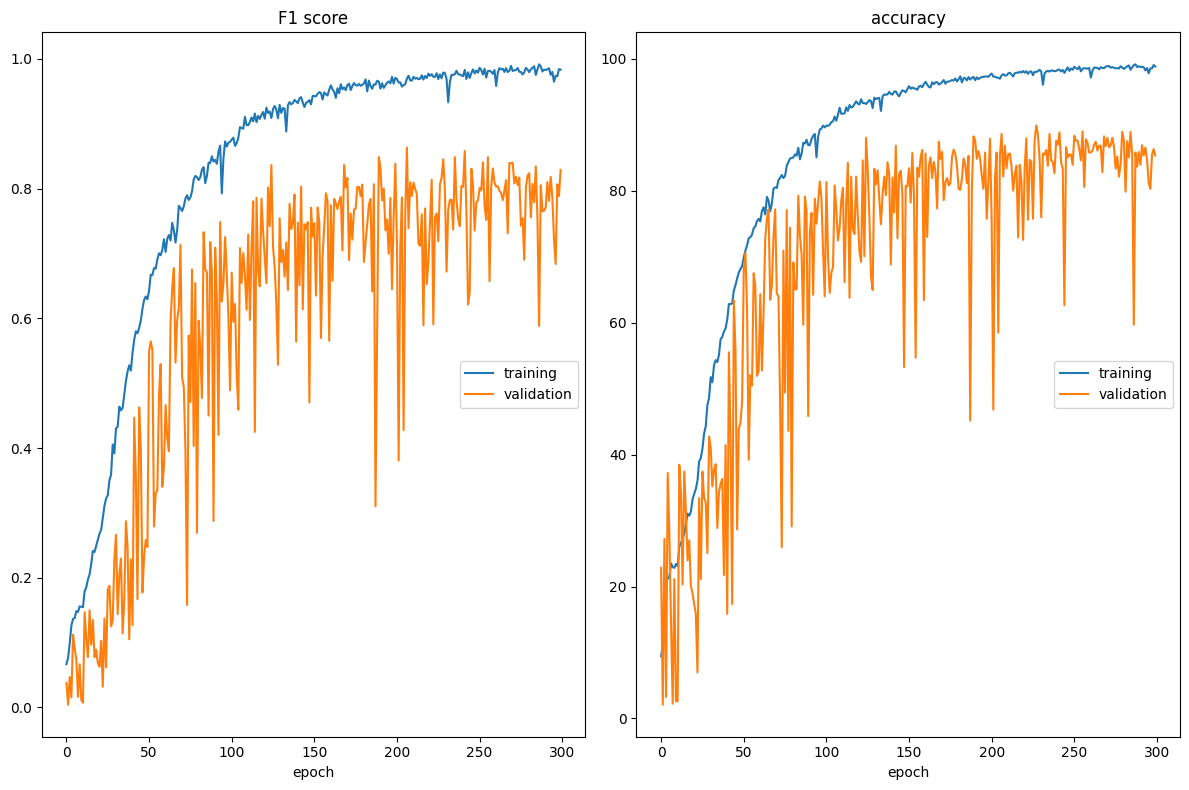

F1 score
	training         	 (min:    0.067, max:    0.992, cur:    0.983)
	validation       	 (min:    0.004, max:    0.863, cur:    0.829)
accuracy
	training         	 (min:    9.450, max:   99.154, cur:   98.839)
	validation       	 (min:    2.083, max:   89.881, cur:   85.342)
train accuracy for this epoch 299 is 98.84%
loss 13525.5254 with epoch time 21.4777 s & computation time 18.8428 s 


In [3]:
logger = train(
    train_dataloader, model, prog_args, val_dataset=test_dataloader, checkpoint=checkpoint
)

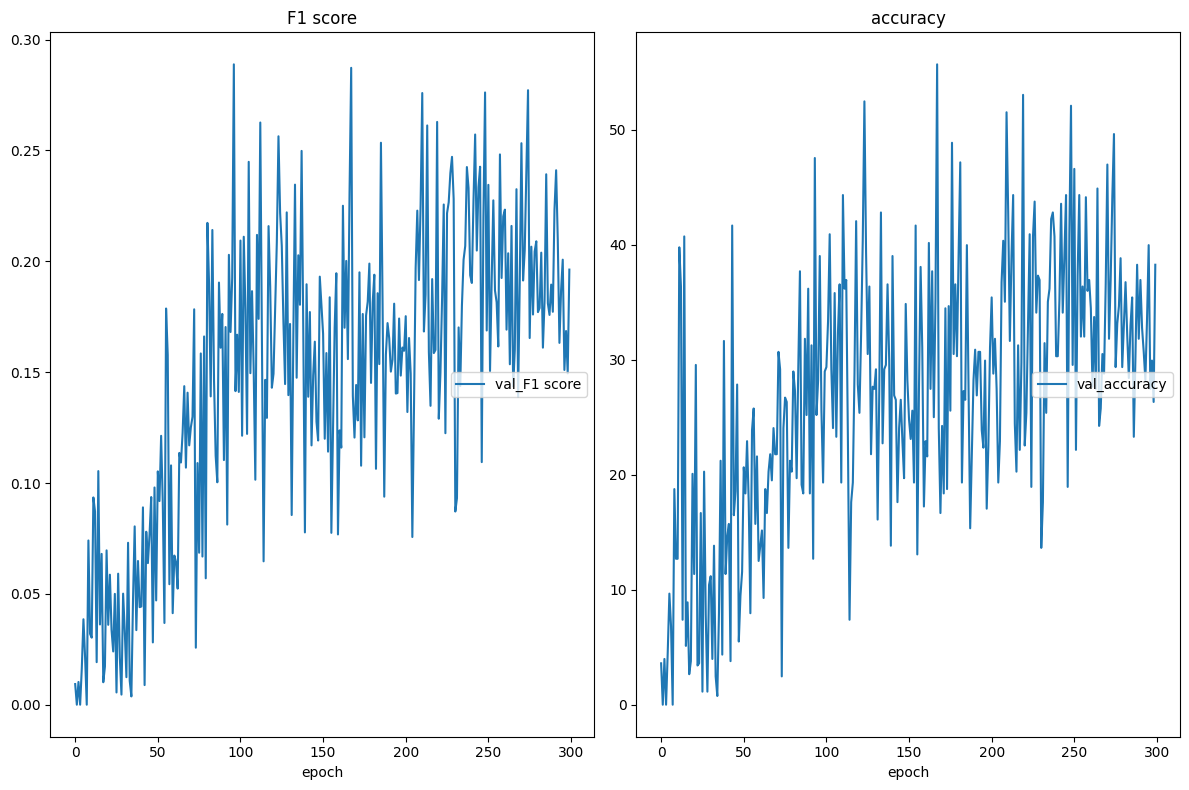

F1 score
	val_F1 score     	 (min:    0.000, max:    0.289, cur:    0.196)
accuracy
	val_accuracy     	 (min:    0.000, max:   55.682, cur:   38.258)


In [4]:
def evaluate(dataloader, model, prog_args, best_epoch=None):
    """
    evaluate function
    """
    if best_epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(best_epoch)
            )
        )
    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
        val_f1_score = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average='macro')
        val_pred_indi = torch.cat((val_pred_indi, torch.tensor([5,7,8], device='cuda')), dim=0)
        val_label_indi = torch.cat((val_label_indi, torch.tensor([6,8,9], device='cuda')), dim=0)
        val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
    result = correct_label / (len(dataloader) * prog_args.batch_size)
    return result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10

liveloss = PlotLosses()
for i in range(0,300):
    result, val_f1_score, _, _, _, _, _, _, _, _, _, _ = evaluate(realtest_dataloader, model, prog_args, best_epoch=i)
    logs = {} # 实时绘制Loss
    logs['val_accuracy'] = result * 100
    logs['val_F1 score'] = val_f1_score
    liveloss.update(logs)
    liveloss.send()


# # 马后炮评测

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # 设置可见的GPU设备

import argparse
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import pandas as pd

sample_redies_udp = 6.0
sample_redies_sugar = 6.0
input_save_dir = 52

# prog_args = argparse.Namespace(dataset=f'udp{sample_redies_udp}_sugar{sample_redies_sugar}', pool_ratio=0.30, num_pool=3, cuda=1, lr=1.0, clip=float("inf"),
#                                batch_size=64, epoch=200, n_worker=2, gc_per_block=3, aggregator_type="meanpool", activation = F.relu, rho = 0.9, eps = 1e-6,
#                                dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_0{input_save_dir}",
#                                load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64)

prog_args = argparse.Namespace(dataset=f'udp{sample_redies_udp}_sugar{sample_redies_sugar}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=48, epoch=300, n_worker=10, gc_per_block=3, aggregator_type="meanpool", activation = F.relu,
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir="./model_param_999",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64)


def prepare_data(dataset, shuffle=False, prog_args=None):
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )


dataset_train = tu.RhaFinderDataset(name="Rha_Finder",
                                    raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/train/')
dataset_test = tu.RhaFinderDataset(name="Rha_Finder",
                                   raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/test/')
dataset_realtest = tu.RhaFinderDataset(name="Rha_Finder",
                                       raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/realtest/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)
realtest_dataloader = prepare_data(dataset_realtest, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
input_dim_realtest, label_dim_realtest, max_num_node_realtest = dataset_realtest.statistics()
max_num_node = max([max_num_node_train, max_num_node_test, max_num_node_realtest])
input_dim = input_dim_train
label_dim = label_dim_train
hidden_dim = prog_args.hidden_dim
embedding_dim = prog_args.embedding_dim
assign_dim = int(max_num_node * prog_args.pool_ratio)
activation = prog_args.activation

model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
)

/home/admin123/software/anaconda3/envs/dgl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


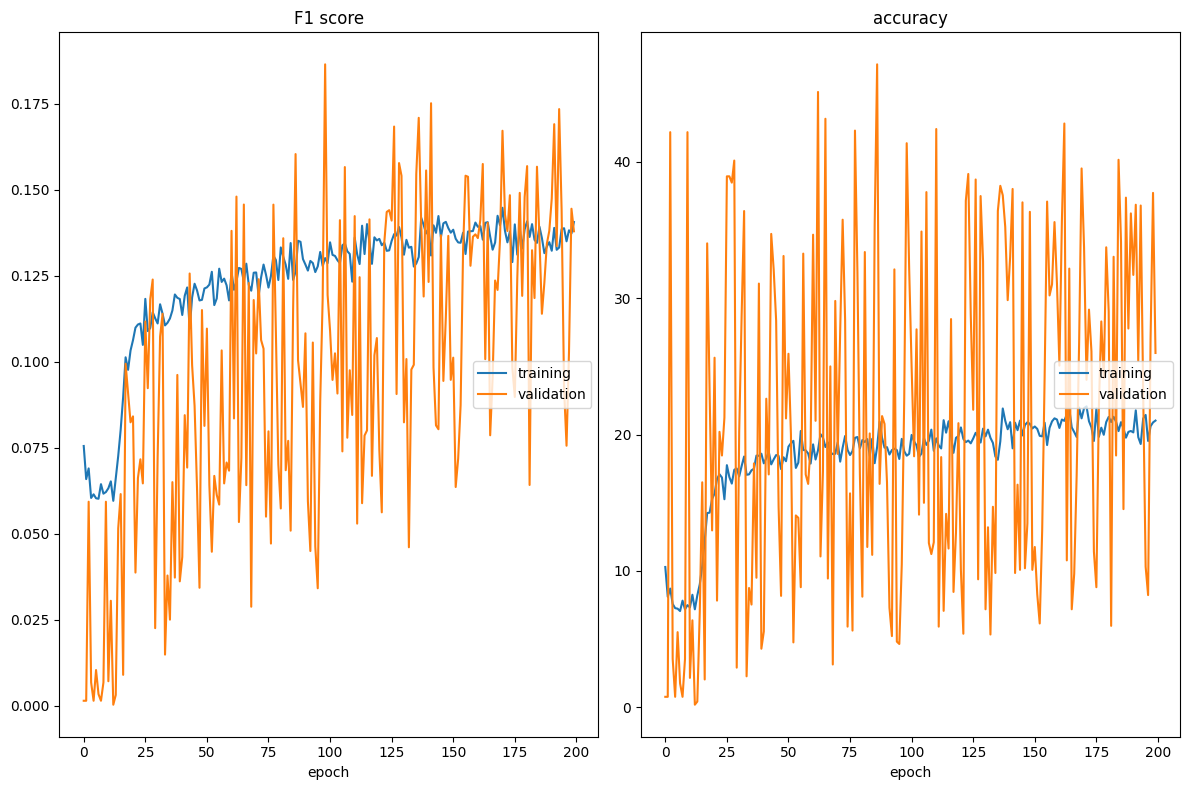

F1 score
	training         	 (min:    0.060, max:    0.145, cur:    0.141)
	validation       	 (min:    0.000, max:    0.186, cur:    0.138)
accuracy
	training         	 (min:    7.046, max:   22.066, cur:   21.023)
	validation       	 (min:    0.174, max:   47.164, cur:   25.984)


In [2]:
df = pd.read_csv(f'./model_param_0{input_save_dir}/udp{sample_redies_udp}_sugar{sample_redies_sugar}/train_log.csv', sep=', ')
liveloss = PlotLosses()
for i in range(len(df)):
    logs = {}  # 实时绘制Loss
    logs['accuracy'] = df['accuracy'][i]
    logs['val_accuracy'] = df['val_accuracy'][i]
    logs['F1 score'] = df['F1 score'][i]
    logs['val_F1 score'] = df['val_F1 score'][i]
    liveloss.update(logs)
    liveloss.send()


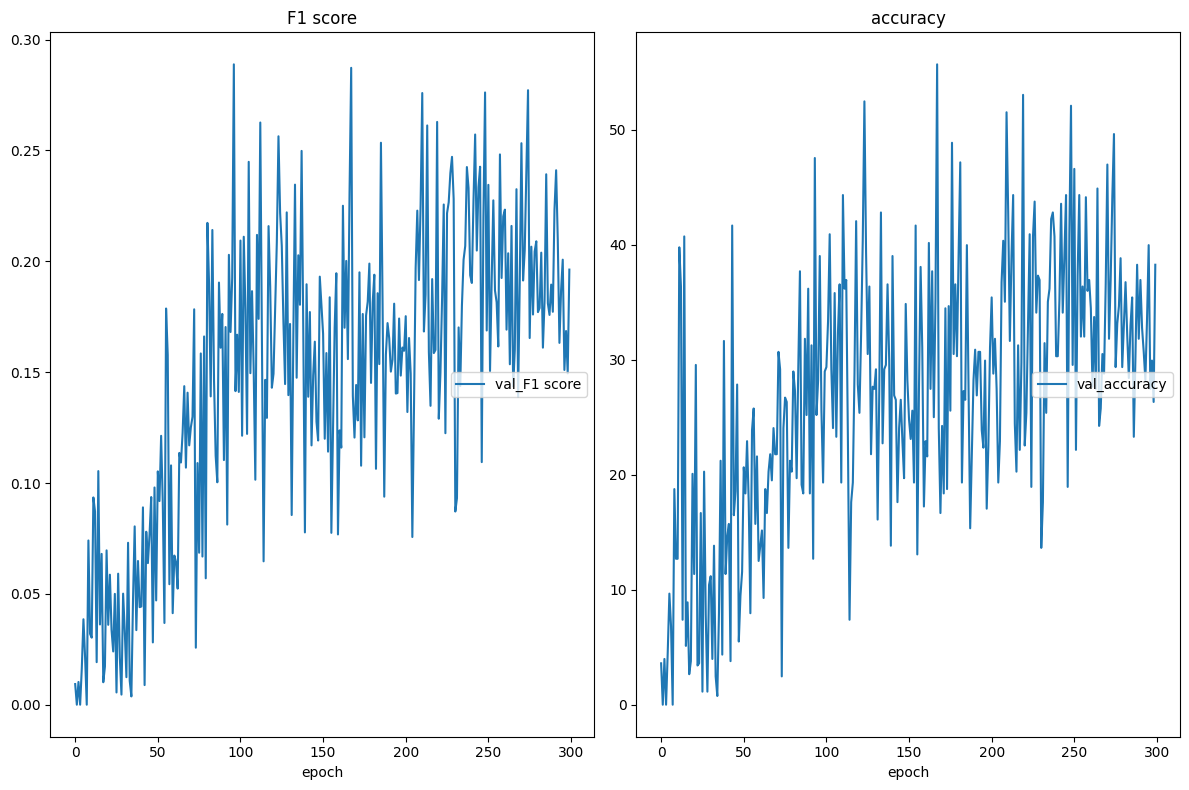

F1 score
	val_F1 score     	 (min:    0.000, max:    0.289, cur:    0.196)
accuracy
	val_accuracy     	 (min:    0.000, max:   55.682, cur:   38.258)


In [2]:
def evaluate(dataloader, model, prog_args, best_epoch=None):
    """
    evaluate function
    """
    if best_epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(best_epoch)
            )
        )
    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
        val_f1_score = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average='macro')
        val_pred_indi = torch.cat((val_pred_indi, torch.tensor([5,7,8], device='cuda')), dim=0)
        val_label_indi = torch.cat((val_label_indi, torch.tensor([6,8,9], device='cuda')), dim=0)
        val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
    result = correct_label / (len(dataloader) * prog_args.batch_size)
    return result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10

if prog_args.cuda > 0:
    torch.cuda.set_device(0)
if prog_args.cuda:
    model = model.cuda()
for epoch in range(1):
    model.train()
    print("\nGenerate model param ###### ######")
    for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
        for key, value in batch_graph.ndata.items():
            batch_graph.ndata[key] = value.float()
        graph_labels = graph_labels.long()
        if torch.cuda.is_available():
            batch_graph = batch_graph.to(torch.cuda.current_device())
            graph_labels = graph_labels.cuda()
        model.zero_grad()
        ypred = model(batch_graph)
    torch.cuda.empty_cache()

liveloss = PlotLosses()
f = open('/home/admin123/work/GTmining/diffpool/model_param_999/Predict_correspond_information.tsv', 'w')
f.write(f"val_accuracy\tval_F1 score\n")
for i in range(0,300):
    result, val_f1_score, _, _, _, _, _, _, _, _, _, _ = evaluate(realtest_dataloader, model, prog_args, best_epoch=i)
    logs = {} # 实时绘制Loss
    logs['val_accuracy'] = result * 100
    logs['val_F1 score'] = val_f1_score
    liveloss.update(logs)
    liveloss.send()
    f.write(f"{result * 100}\t{val_f1_score}\n")

f.close()


# # loss检查

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # 设置可见的GPU设备

import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import pandas as pd

sample_redies_udp = 6.0
sample_redies_sugar = 6.0
input_save_dir = 51

prog_args = argparse.Namespace(dataset=f'udp{sample_redies_udp}_sugar{sample_redies_sugar}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=48, epoch=300, n_worker=10, gc_per_block=3, aggregator_type="meanpool", activation = F.relu,
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir="./try_param/model_param_999",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64)


def prepare_data(dataset, shuffle=False, prog_args=None):
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )


dataset_train = tu.RhaFinderDataset(name="Rha_Finder",
                                    raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/train/')
dataset_test = tu.RhaFinderDataset(name="Rha_Finder",
                                   raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/test/')
dataset_realtest = tu.RhaFinderDataset(name="Rha_Finder",
                                       raw_dir=f'../data/local_features/dl_data/udp{sample_redies_udp}_sugar{sample_redies_sugar}/realtest/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)
realtest_dataloader = prepare_data(dataset_realtest, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
input_dim_realtest, label_dim_realtest, max_num_node_realtest = dataset_realtest.statistics()
max_num_node = max([max_num_node_train, max_num_node_test, max_num_node_realtest])
input_dim = input_dim_train
label_dim = label_dim_train
hidden_dim = prog_args.hidden_dim
embedding_dim = prog_args.embedding_dim
assign_dim = int(max_num_node * prog_args.pool_ratio)
activation = prog_args.activation

model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
)

/home/admin123/software/anaconda3/envs/dgl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


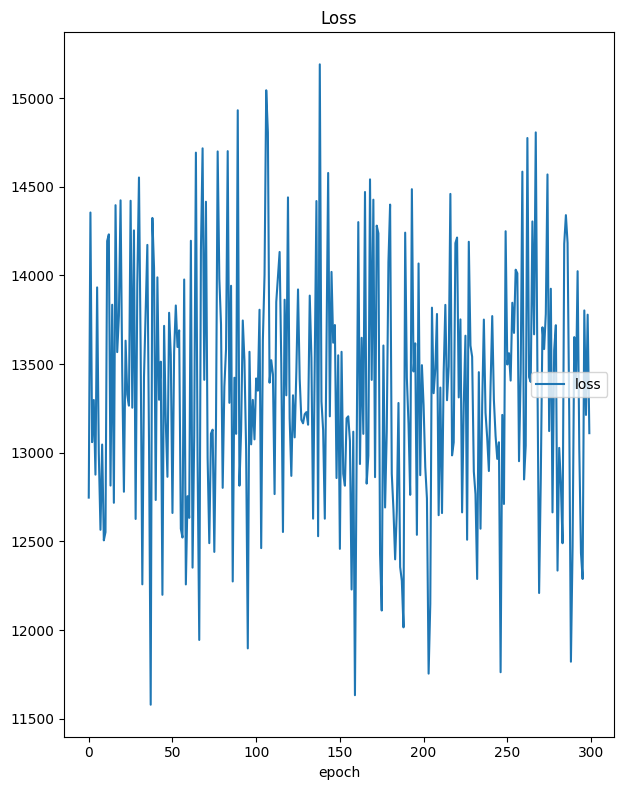

Loss
	loss             	 (min: 11579.565, max: 15189.832, cur: 13110.512)


In [2]:
def evaluate(dataloader, model, prog_args, best_epoch=None):
    """
    evaluate function
    """
    if best_epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(best_epoch)
            )
        )
    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            loss = model.loss(ypred, graph_labels)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
        val_f1_score = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average='macro')
        val_pred_indi = torch.cat((val_pred_indi, torch.tensor([5,7,8], device='cuda')), dim=0)
        val_label_indi = torch.cat((val_label_indi, torch.tensor([6,8,9], device='cuda')), dim=0)
        val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10 = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average=None)
    result = correct_label / (len(dataloader) * prog_args.batch_size)
    # return result, val_f1_score, val_f1_score_class_1, val_f1_score_class_2, val_f1_score_class_3, val_f1_score_class_4, val_f1_score_class_5, val_f1_score_class_6, val_f1_score_class_7, val_f1_score_class_8, val_f1_score_class_9, val_f1_score_class_10
    return loss

if prog_args.cuda > 0:
    torch.cuda.set_device(0)
if prog_args.cuda:
    model = model.cuda()
for epoch in range(1):
    model.train()
    print("\nGenerate model param ###### ######")
    for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
        for key, value in batch_graph.ndata.items():
            batch_graph.ndata[key] = value.float()
        graph_labels = graph_labels.long()
        if torch.cuda.is_available():
            batch_graph = batch_graph.to(torch.cuda.current_device())
            graph_labels = graph_labels.cuda()
        model.zero_grad()
        ypred = model(batch_graph)
    torch.cuda.empty_cache()

liveloss = PlotLosses()
for i in range(0,300):
    loss = evaluate(train_dataloader, model, prog_args, best_epoch=i)
    logs = {} # 实时绘制Loss
    logs['loss'] = loss.cpu()
    liveloss.update(logs)
    liveloss.send()

